# Notebook 05 - Score Regression

Predicting the exam score on DS3, the dataset that actually has feature signal
(DS2's exam score was uncorrelated with everything, so it sits aside as a
control). This notebook also covers the model search I did before settling on a
final regressor: interaction features, an expanded XGBoost grid, and a LightGBM
comparison.



Data is the six DS3 predictors, split 8000/2000.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from tabulate import tabulate

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "ml" / "config.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ml import config
from ml.regression import AcademicScorePredictor, add_interaction_features
from ml.preprocessing import prepare_regression_data

sns.set_theme(style="whitegrid")

data = prepare_regression_data(save=False)
print(config.DS3_FEATURES)
data["X_train"].shape, data["X_test"].shape

['study_hours', 'attendance', 'sleep_hours', 'internet_usage', 'assignments_completed', 'previous_score']


((8000, 6), (2000, 6))

On top of the six base features I add a handful of pairwise products that
should matter for a score: effort against engagement, effort against prior
ability, and so on. DS3 has no stress column so the sleep-with-stress idea isn't
possible here; sleep is paired with study hours instead.

In [2]:
add_interaction_features(data["X_train"]).head(3)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,study_hours_x_attendance,study_hours_x_assignments_completed,attendance_x_previous_score,study_hours_x_previous_score,sleep_hours_x_study_hours,internet_usage_x_study_hours
9254,11,58,5,7,5,70,638,55,4060,770,55,77
1561,11,93,4,10,0,83,1023,0,7719,913,44,110
1670,7,86,7,5,14,85,602,98,7310,595,49,35


Fit and compare. The random forest and XGBoost are both grid-searched
(XGBoost over the expanded grid: n_estimators, max_depth, learning_rate,
subsample, colsample_bytree). This cell does the real searching so it takes a
minute or two.

In [3]:
predictor = AcademicScorePredictor().fit(
    data["X_train"], data["y_train"], data["X_test"], data["y_test"]
)
print("RF best :", predictor.rf_best_params_)
print("XGB best:", predictor.xgb_best_params_)
print()
print(tabulate(predictor.metrics_, headers="keys", tablefmt="github"))
print("\nBest by test RMSE:", predictor.best_name_)

RF best : {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}
XGB best: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 500, 'subsample': 0.8}

| model             |   train_rmse |   test_rmse |   test_mae |   test_r2 |
|-------------------|--------------|-------------|------------|-----------|
| linear_regression |        8.093 |       8.162 |      6.233 |     0.71  |
| random_forest     |        5.773 |       7.93  |      5.723 |     0.726 |
| xgboost           |        6.416 |       7.773 |      5.593 |     0.737 |

Best by test RMSE: xgboost


XGBoost wins at R-squared 0.737 (RMSE 7.77). For context, the plain
six-feature XGBoost from the first pass sat at 0.727 / 7.93. The interactions
plus the expanded grid lift it to 0.737, and a 5-fold cross-validated check put
the gain at about +0.013 R-squared, consistent across every fold. Worth noting the interactions help linear regression the
most (0.66 to 0.71), which is expected since the trees were already capturing
those interactions on their own.

LightGBM as a fourth model, on the same interaction features, to see if a
different gradient-boosting implementation does better.

In [4]:
def evaluate(model, x, y, name):
    pred = model.predict(x)
    return {
        "model": name,
        "test_rmse": round(root_mean_squared_error(y, pred), 3),
        "test_mae": round(mean_absolute_error(y, pred), 3),
        "test_r2": round(r2_score(y, pred), 3),
    }


x_test_aug = add_interaction_features(data["X_test"])
lgbm = LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=config.RANDOM_SEED, verbose=-1)
lgbm.fit(add_interaction_features(data["X_train"]), data["y_train"])

comparison = pd.DataFrame(
    [
        evaluate(predictor.models_["linear_regression"], x_test_aug, data["y_test"], "linear_regression"),
        evaluate(predictor.models_["random_forest"], x_test_aug, data["y_test"], "random_forest"),
        evaluate(predictor.models_["xgboost"], x_test_aug, data["y_test"], "xgboost"),
        evaluate(lgbm, x_test_aug, data["y_test"], "lightgbm"),
    ]
).set_index("model").sort_values("test_r2", ascending=False)
print(tabulate(comparison, headers="keys", tablefmt="github"))

| model             |   test_rmse |   test_mae |   test_r2 |
|-------------------|-------------|------------|-----------|
| xgboost           |       7.773 |      5.593 |     0.737 |
| random_forest     |       7.93  |      5.723 |     0.726 |
| lightgbm          |       7.999 |      5.709 |     0.721 |
| linear_regression |       8.162 |      6.233 |     0.71  |


LightGBM lands just below XGBoost, so it doesn't earn a place as the
production model. It stays as something i tried but did not outperform my xgb.

Diagnostics for the chosen model: predicted vs actual, residual spread,
and a learning curve.

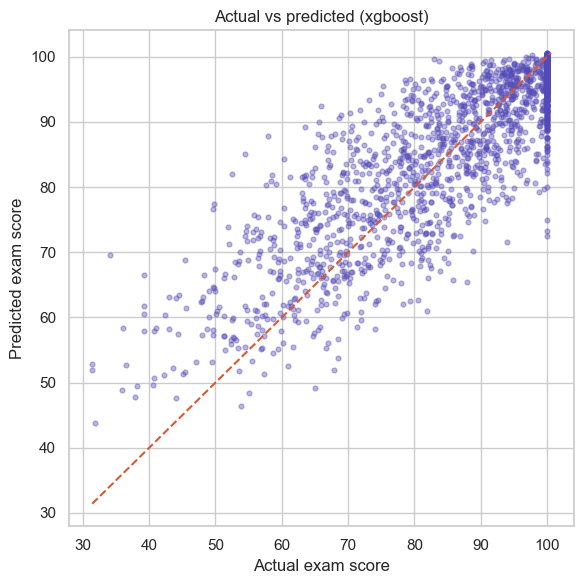

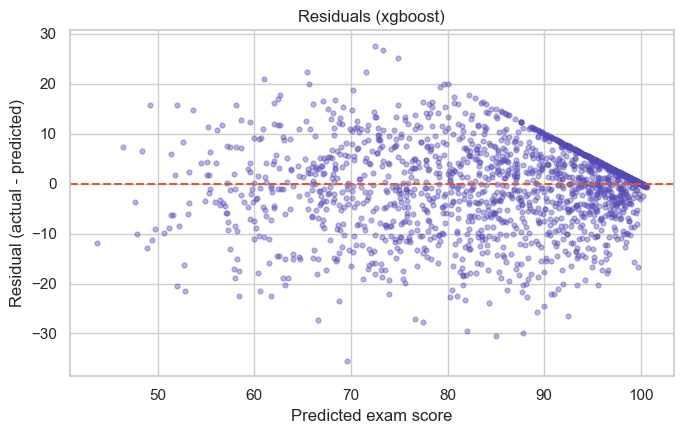

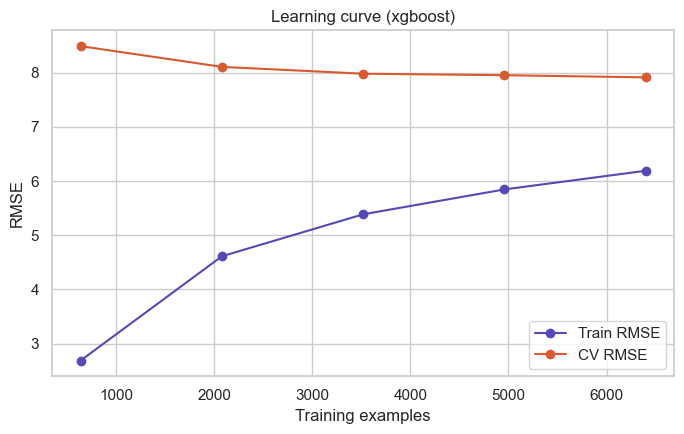

In [5]:
predictor.plot_actual_vs_predicted(
    data["X_test"], data["y_test"], config.PLOTS_DIR / "regression_actual_vs_predicted.png"
)
predictor.plot_residuals(
    data["X_test"], data["y_test"], config.PLOTS_DIR / "regression_residuals.png"
)
predictor.plot_learning_curve(
    data["X_train"], data["y_train"], config.PLOTS_DIR / "regression_learning_curve.png"
);

Residuals are roughly symmetric around zero with no strong fan, and the
learning curve's train and CV lines converge, so the model is data-sufficient.
So for now i will just save the best estimator. It's stored bare and the inference pipeline rebuilds the
interaction features before calling it.

In [6]:
predictor.save()

## Key takeaways

- Final regressor is XGBoost with interaction features and an expanded grid:
  test R-squared 0.737, RMSE 7.77, up from 0.727 on the plain six features. The
  gain is small but it held up under cross-validation.
- LightGBM was tested fairly and came in just behind XGBoost, so it wasn't
  adopted.
- DS4 stays untouched. The DS2 control and DS4 holdout transfer are the
  cross-dataset step, not this one.